In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.columns.tolist())
print(df['Churn'].value_counts())

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Churn
No     5174
Yes    1869
Name: count, dtype: int64


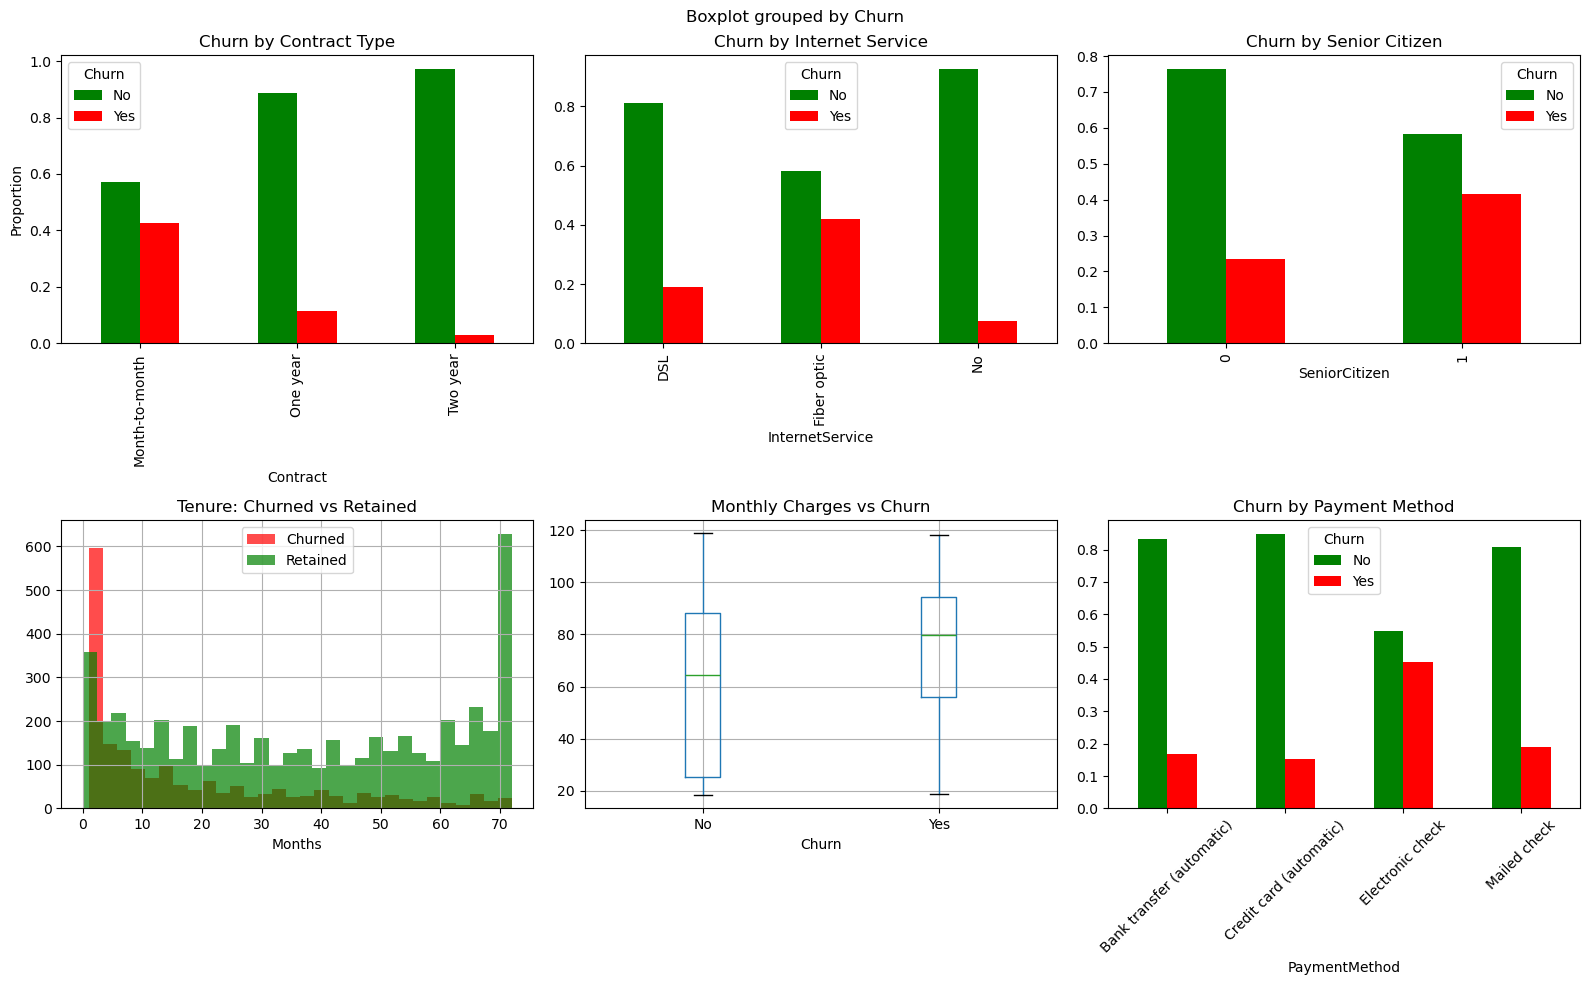

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Contract type vs churn
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[0,0], color=['green','red'])
axes[0,0].set_title('Churn by Contract Type')
axes[0,0].set_ylabel('Proportion')

# 2. Internet service vs churn
df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[0,1], color=['green','red'])
axes[0,1].set_title('Churn by Internet Service')

# 3. Senior citizen vs churn
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[0,2], color=['green','red'])
axes[0,2].set_title('Churn by Senior Citizen')

# 4. Tenure distribution
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[1,0], color='red', alpha=0.7, bins=30)
df[df['Churn']=='No']['tenure'].hist(ax=axes[1,0], color='green', alpha=0.7, bins=30)
axes[1,0].set_title('Tenure: Churned vs Retained')
axes[1,0].set_xlabel('Months')
axes[1,0].legend(['Churned','Retained'])

# 5. Monthly charges vs churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1,1])
axes[1,1].set_title('Monthly Charges vs Churn')

# 6. Payment method vs churn
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[1,2], color=['green','red'])
axes[1,2].set_title('Churn by Payment Method')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()